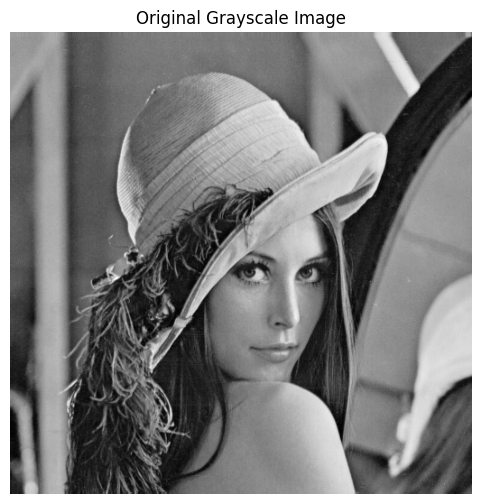

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = 'input.png' # Replace with your image path
image = cv2.imread(img_path)

if image is None:
    print("Error: Could not load image. Please check the path.")
else:
    # Convert to grayscale for texture analysis
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(gray_img, cmap='gray')
    plt.title("Original Grayscale Image")
    plt.axis('off')
    plt.show()

In [2]:
def apply_gabor(img, theta, lamda=10.0, sigma=5.0, gamma=0.5, phi=0):
    """
    Applies a Gabor filter to the input image.
    theta: Orientation in radians
    lamda: Wavelength of the sinusoidal factor
    sigma: Standard deviation of the Gaussian envelope
    gamma: Spatial aspect ratio
    """
    kernel_size = 31 # Size of the filter matrix
    # Create the Gabor Kernel
    kernel = cv2.getGaborKernel((kernel_size, kernel_size), sigma, theta, lamda, gamma, phi, ktype=cv2.CV_32F)
    
    # Filter the image
    fimg = cv2.filter2D(img, cv2.CV_8U, kernel)
    return fimg, kernel
    

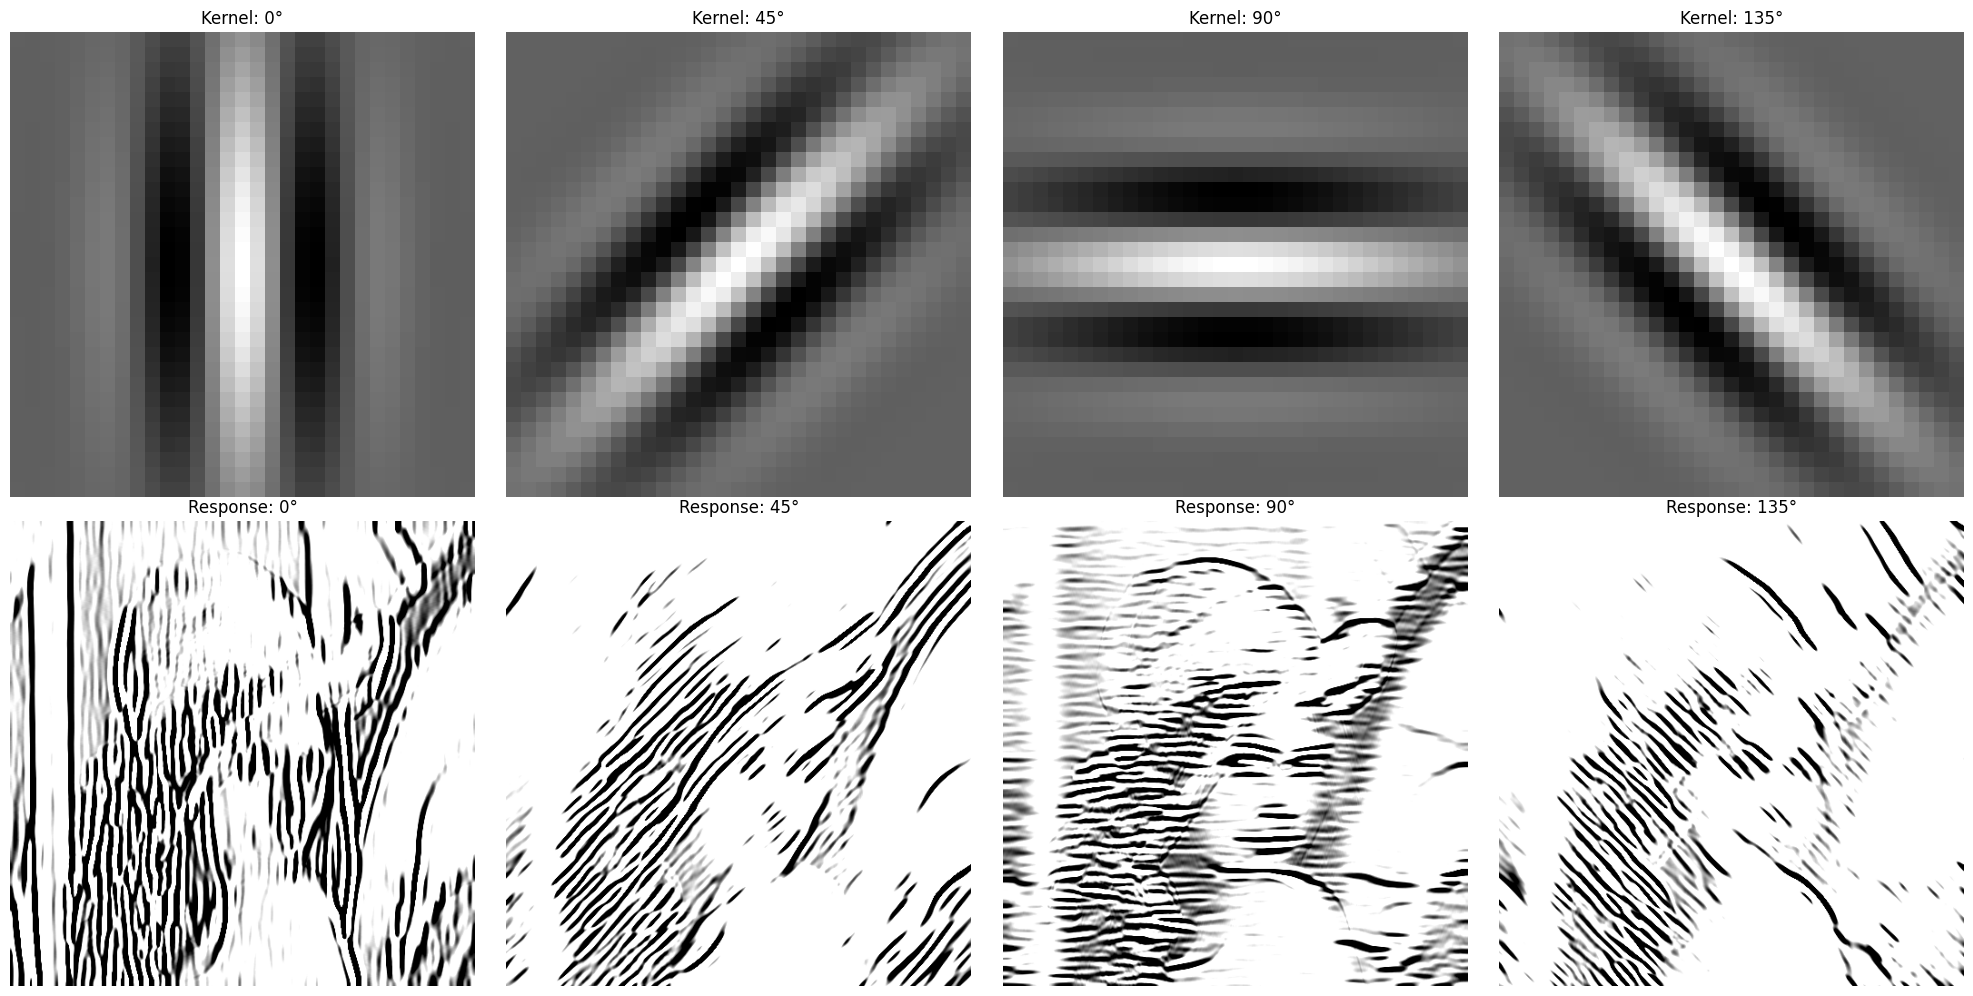

In [3]:
orientations = [0, 45, 90, 135]
theta_rads = [np.deg2rad(t) for t in orientations]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, theta in enumerate(theta_rads):
    filtered_res, kernel = apply_gabor(gray_img, theta)
    
    # Display the Kernel (how the filter looks)
    axes[0, i].imshow(kernel, cmap='gray')
    axes[0, i].set_title(f"Kernel: {orientations[i]}°")
    axes[0, i].axis('off')
    
    # Display the Filtered Output
    axes[1, i].imshow(filtered_res, cmap='gray')
    axes[1, i].set_title(f"Response: {orientations[i]}°")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()